In [1]:
# STEP 1: Install and import required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# STEP 2: Check GPU availability

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

!nvidia-smi

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Wed May 20 17:21:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                              

In [6]:
# STEP 3: Install Kaggle
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"johncojocaru","key":"e890a5b499ecef8414a5c61c243d03c8"}'}

In [4]:
# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip
!unzip -q chest-xray-pneumonia.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:56<00:00, 43.4MB/s]



In [8]:
# STEP 4: Verify dataset and ignore hidden files

import os

base_dir = "/content/chest_xray/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

for folder in [train_dir, val_dir, test_dir]:
    print("\n", folder)
    for label in os.listdir(folder):
        path = os.path.join(folder, label)

        # Ignore hidden files such as .DS_Store
        if os.path.isdir(path):
            print(label, len(os.listdir(path)))


 /content/chest_xray/chest_xray/train
NORMAL 1342
PNEUMONIA 3876

 /content/chest_xray/chest_xray/val
NORMAL 9
PNEUMONIA 9

 /content/chest_xray/chest_xray/test
NORMAL 234
PNEUMONIA 390


In [10]:
# STEP 5: Improved Data Preprocessing with Validation Split

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator with validation split
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Test generator only rescales images
test_datagen = ImageDataGenerator(rescale=1./255)

# Training data: 80% of original training folder
train_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Validation data: 20% of original training folder
val_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Test data: original Kaggle test folder
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [11]:
# STEP 6: Checkpoint Saving, Early Stopping, and Class Weights

import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.callbacks import CSVLogger, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Folder where model checkpoints will be saved
checkpoint_dir = "/content/model_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Custom callback to save model after every 10 epochs
class SaveEveryNEpochs(tf.keras.callbacks.Callback):
    def __init__(self, model_name, save_every=10):
        super().__init__()
        self.model_name = model_name
        self.save_every = save_every

    def on_epoch_end(self, epoch, logs=None):
        epoch_number = epoch + 1

        if epoch_number % self.save_every == 0:
            save_path = os.path.join(
                checkpoint_dir,
                f"{self.model_name}_epoch_{epoch_number}.keras"
            )
            self.model.save(save_path)
            print(f"\nSaved checkpoint: {save_path}")

# Calculate class weights to reduce the effect of dataset imbalance
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights_values))

print("Class weights:", class_weights)
print("Checkpoint and class-weight setup complete.")

Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}
Checkpoint and class-weight setup complete.


In [13]:
# STEP 7: Build and Train Baseline CNN for up to 50 Epochs

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping

baseline_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

baseline_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_cnn.summary()

baseline_callbacks = [
    SaveEveryNEpochs("baseline_cnn", save_every=10),
    CSVLogger("/content/baseline_cnn_training_log.csv", append=False),
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
]

history_baseline = baseline_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=baseline_callbacks,
    class_weight=class_weights
)

baseline_cnn.save("/content/baseline_cnn_final.keras")
print("Baseline CNN training complete and saved.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 850ms/step - accuracy: 0.7635 - loss: 0.4944 - val_accuracy: 0.8792 - val_loss: 0.2948
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 816ms/step - accuracy: 0.8835 - loss: 0.2853 - val_accuracy: 0.8734 - val_loss: 0.3189
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 824ms/step - accuracy: 0.9101 - loss: 0.2269 - val_accuracy: 0.9156 - val_loss: 0.1896
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 833ms/step - accuracy: 0.9125 - loss: 0.2196 - val_accuracy: 0.9243 - val_loss: 0.1916
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 821ms/step - accuracy: 0.9176 - loss: 0.2024 - val_accuracy: 0.9137 - val_loss: 0.2249
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 817ms/step - accuracy: 0.9214 - loss: 0.2071 - val_accuracy: 0.8562 - val_loss: 0.3436
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 843ms/step - accuracy: 0.9310 - loss: 0.1728 - val_accuracy: 0.9214 - val_loss: 0.1807
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 837ms/step - accuracy: 0.9331 -

In [14]:
# STEP 8: Build and Train VGG16 for up to 50 Epochs

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping

# Load pretrained VGG16 base model
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
for layer in vgg_base.layers:
    layer.trainable = False

# Add custom classification layers
vgg_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

vgg_callbacks = [
    SaveEveryNEpochs("vgg16", save_every=10),
    CSVLogger("/content/vgg16_training_log.csv", append=False),
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
]

history_vgg = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=vgg_callbacks,
    class_weight=class_weights
)

vgg_model.save("/content/vgg16_final.keras")
print("VGG16 training complete and saved.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8759 - loss: 0.3212 - val_accuracy: 0.9185 - val_loss: 0.1964
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 898ms/step - accuracy: 0.9272 - loss: 0.1877 - val_accuracy: 0.9511 - val_loss: 0.1133
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 895ms/step - accuracy: 0.9283 - loss: 0.1829 - val_accuracy: 0.9262 - val_loss: 0.1789
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 117s 894ms/step - accuracy: 0.9420 - loss: 0.1578 - val_accuracy: 0.9233 - val_loss: 0.1710
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 117s 896ms/step - accuracy: 0.9422 - loss: 0.1472 - val_accuracy: 0.9626 - val_loss: 0.1046
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 116s 888ms/step - accuracy: 0.9444 - loss: 0.1419 - val_accuracy: 0.9597 - val_loss: 0.0983
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 117s 895ms/step - accuracy: 0.9399 - loss: 0.1416 - val_accuracy: 0.9616 - val_loss: 0.1159
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 116s 889ms/step - accuracy: 0.9509 - lo

In [15]:
# STEP 9: Build and Train ResNet50 for up to 50 Epochs

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping

# Load pretrained ResNet50 base model
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
for layer in resnet_base.layers:
    layer.trainable = False

# Add custom classification layers
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

resnet_callbacks = [
    SaveEveryNEpochs("resnet50", save_every=10),
    CSVLogger("/content/resnet50_training_log.csv", append=False),
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
]

history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=resnet_callbacks,
    class_weight=class_weights
)

resnet_model.save("/content/resnet50_final.keras")
print("ResNet50 training complete and saved.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 139s 953ms/step - accuracy: 0.5811 - loss: 0.6925 - val_accuracy: 0.3557 - val_loss: 0.7326
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 840ms/step - accuracy: 0.6401 - loss: 0.6366 - val_accuracy: 0.7785 - val_loss: 0.5578
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 834ms/step - accuracy: 0.7362 - loss: 0.5854 - val_accuracy: 0.7488 - val_loss: 0.5771
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 112s 852ms/step - accuracy: 0.7577 - loss: 0.5370 - val_accuracy: 0.7565 - val_loss: 0.5031
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 861ms/step - accuracy: 0.7836 - loss: 0.5041 - val_accuracy: 0.7613 - val_loss: 0.5249
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 111s 853ms/step - accuracy: 0.7872 - loss: 0.4838 - val_accuracy: 0.7737 - val_loss: 0.4751
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 861ms/step - accuracy: 0.7930 - loss: 0.4687 - val_accuracy: 0.7814 - val_loss: 0.4416
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 904ms/step - accuracy: 0.7987 -

In [16]:
# STEP 10: Final Evaluation Metrics for All Models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# True labels from test dataset
y_true = test_generator.classes

def evaluate_model(model, model_name):
    print(f"\n==============================")
    print(f"Evaluation for: {model_name}")
    print(f"==============================")

    # Predict probabilities
    y_pred_prob = model.predict(test_generator)

    # Convert probabilities to class labels
    y_pred = (y_pred_prob > 0.5).astype(int).ravel()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    specificity = TN / (TN + FP)
    roc_auc = roc_auc_score(y_true, y_pred_prob)

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

    print("Confusion Matrix:")
    print(cm)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall/Sensitivity: {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm,
        "Predicted Probabilities": y_pred_prob,
        "Predicted Classes": y_pred
    }

# Evaluate all models on the same test set
baseline_results = evaluate_model(baseline_cnn, "Baseline CNN")
vgg_results = evaluate_model(vgg_model, "VGG16")
resnet_results = evaluate_model(resnet_model, "ResNet50")


Evaluation for: Baseline CNN
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.57      0.72       234
   PNEUMONIA       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.78      0.80       624
weighted avg       0.86      0.83      0.82       624

Confusion Matrix:
[[134 100]
 [  5 385]]
Accuracy: 0.8317
Precision: 0.7938
Recall/Sensitivity: 0.9872
Specificity: 0.5726
F1-score: 0.8800
ROC-AUC: 0.9477

Evaluation for: VGG16
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 748ms/step
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.73      0.83       234
   PNEUMONIA       0.86      0.98      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.87       624
weighted avg       0.90      0.89      0.88       624

Confusio

In [17]:
# STEP 10B: Create Results Comparison Table

results_df = pd.DataFrame([
    {k: v for k, v in baseline_results.items() if k not in ["Confusion Matrix", "Predicted Probabilities", "Predicted Classes"]},
    {k: v for k, v in vgg_results.items() if k not in ["Confusion Matrix", "Predicted Probabilities", "Predicted Classes"]},
    {k: v for k, v in resnet_results.items() if k not in ["Confusion Matrix", "Predicted Probabilities", "Predicted Classes"]}
])

results_df

,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC
0,Baseline CNN,0.831731,0.793814,0.987179,0.572650,0.880000,0.947666
1,VGG16,0.887821,0.857143,0.984615,0.726496,0.916468,0.967373
2,ResNet50,0.782051,0.812808,0.846154,0.675214,0.829146,0.851425


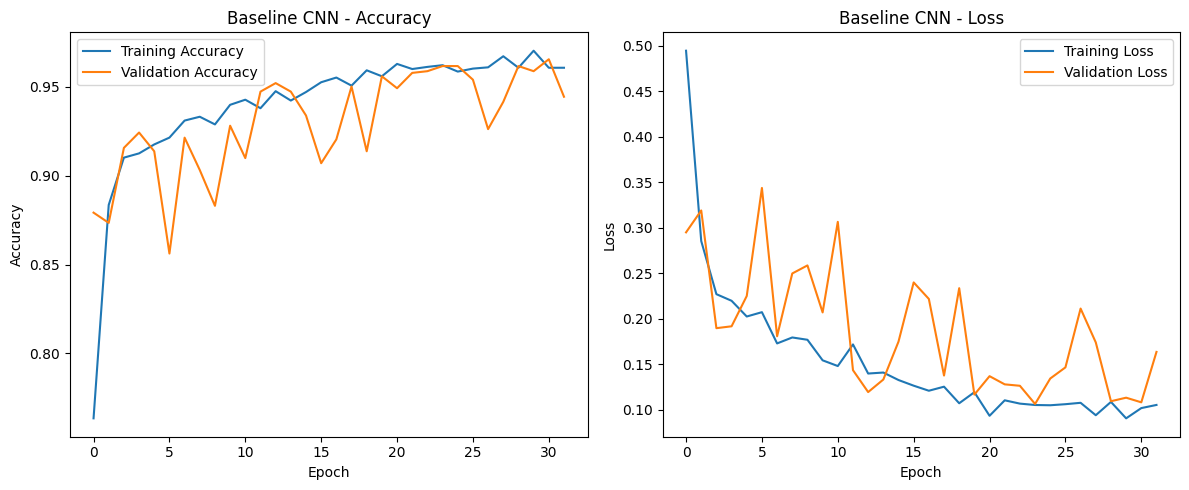

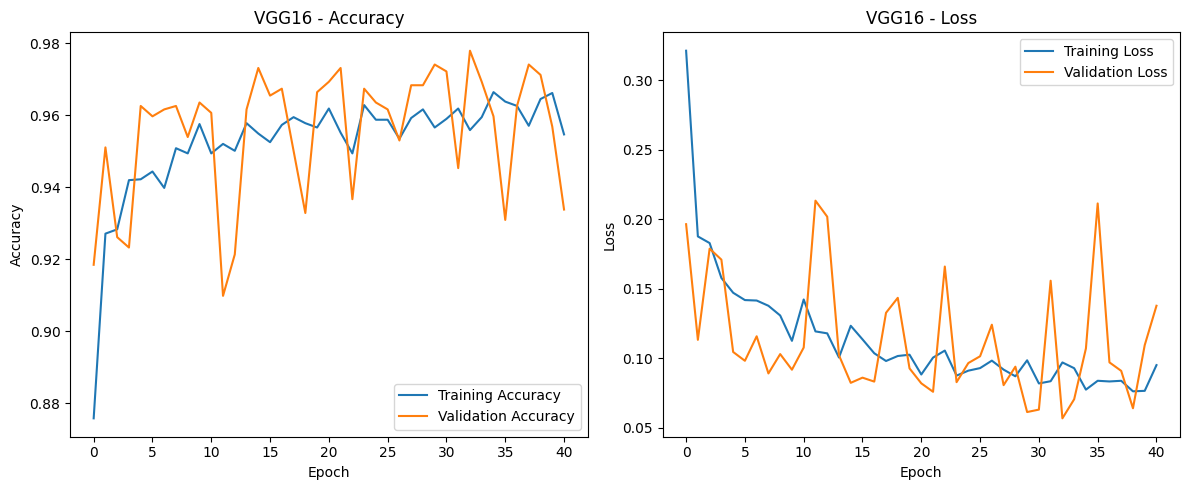

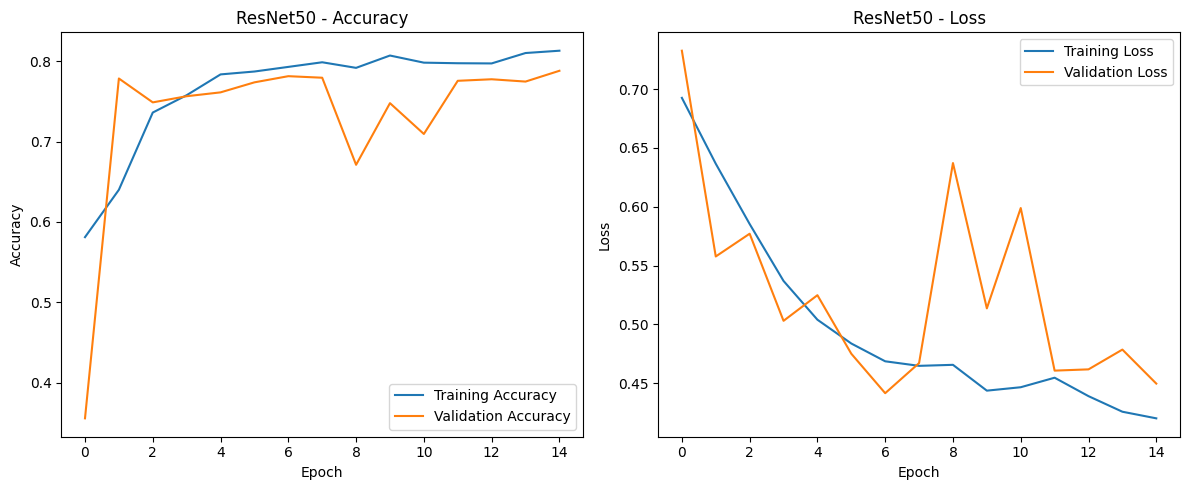

In [18]:
# STEP 11: Plot Accuracy and Loss for All Models

import matplotlib.pyplot as plt

def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot each model separately
plot_training_history(history_baseline, "Baseline CNN")
plot_training_history(history_vgg, "VGG16")
plot_training_history(history_resnet, "ResNet50")

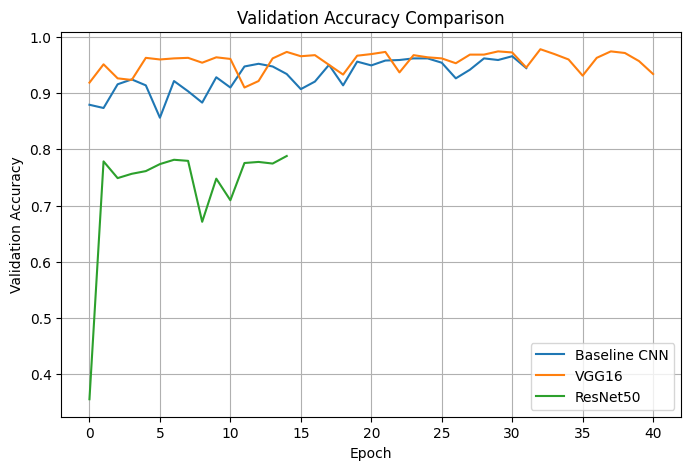

In [19]:
# STEP 11B: Combined Validation Accuracy Comparison

plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["val_accuracy"], label="Baseline CNN")
plt.plot(history_vgg.history["val_accuracy"], label="VGG16")
plt.plot(history_resnet.history["val_accuracy"], label="ResNet50")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

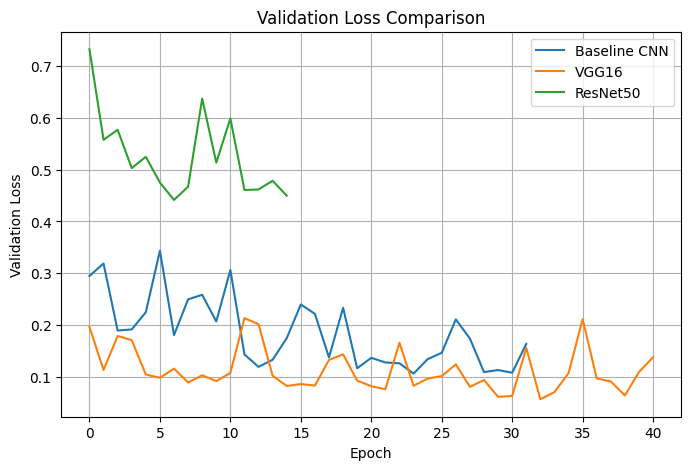

In [20]:
# STEP 11C: Combined Validation Loss Comparison

plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["val_loss"], label="Baseline CNN")
plt.plot(history_vgg.history["val_loss"], label="VGG16")
plt.plot(history_resnet.history["val_loss"], label="ResNet50")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

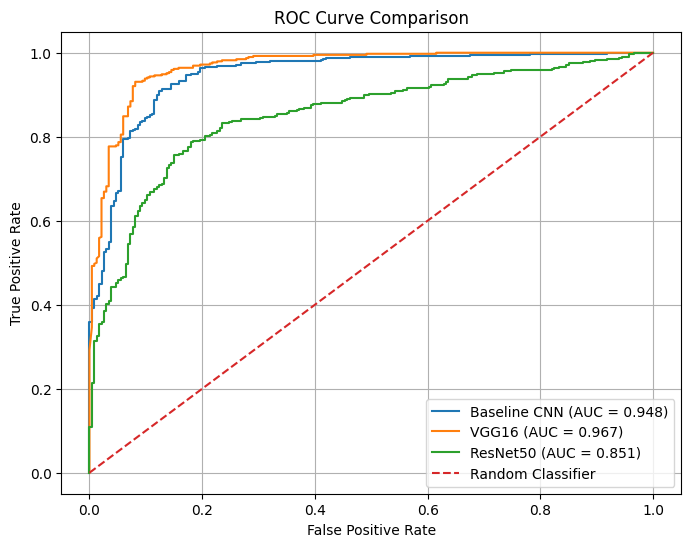

In [21]:
# Step 12 — ROC Curve and Confusion Matrices

# STEP 12A: ROC Curve Comparison for All Models

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for result in [baseline_results, vgg_results, resnet_results]:
    fpr, tpr, _ = roc_curve(y_true, result["Predicted Probabilities"])
    plt.plot(
        fpr,
        tpr,
        label=f"{result['Model']} (AUC = {result['ROC-AUC']:.3f})"
    )

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

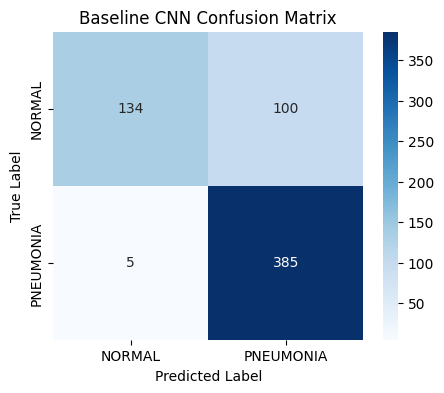

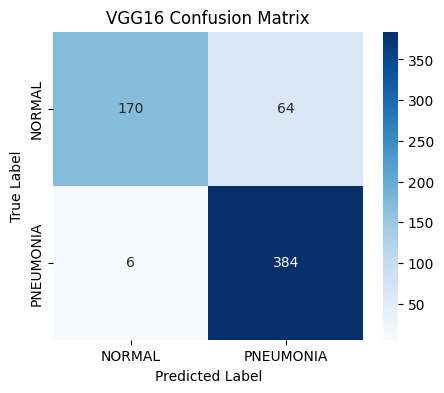

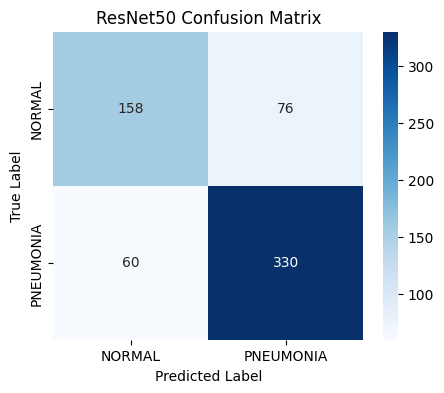

In [22]:
# STEP 12B: Confusion Matrix Plots for All Models

import matplotlib.pyplot as plt
import seaborn as sns

for result in [baseline_results, vgg_results, resnet_results]:
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        result["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["NORMAL", "PNEUMONIA"],
        yticklabels=["NORMAL", "PNEUMONIA"]
    )

    plt.title(f"{result['Model']} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


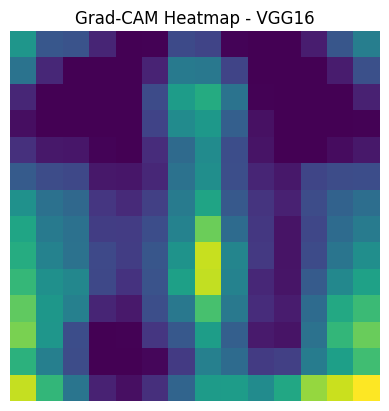

In [23]:
# STEP 13A: Final Grad-CAM for Updated VGG16 Model

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

# Select one test image
img_path = test_generator.filepaths[0]

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Force model call
_ = vgg_model.predict(img_array)

# Get VGG16 base model
vgg_base = vgg_model.layers[0]

# Last convolutional layer of VGG16
last_conv_layer = vgg_base.get_layer("block5_conv3")

# Build Grad-CAM model
grad_model = tf.keras.models.Model(
    inputs=vgg_base.input,
    outputs=[last_conv_layer.output, vgg_base.output]
)

# Classifier layers after VGG16 base
classifier_layers = vgg_model.layers[1:]

with tf.GradientTape() as tape:
    conv_outputs, base_output = grad_model(img_array)
    x = base_output

    for layer in classifier_layers:
        x = layer(x)

    prediction = x
    loss = prediction[:, 0]

# Compute gradients
grads = tape.gradient(loss, conv_outputs)

# Pool gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Generate heatmap
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Normalise heatmap safely
heatmap = tf.maximum(heatmap, 0)
heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
heatmap = heatmap.numpy()

# Display heatmap
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap - VGG16")
plt.axis("off")
plt.show()

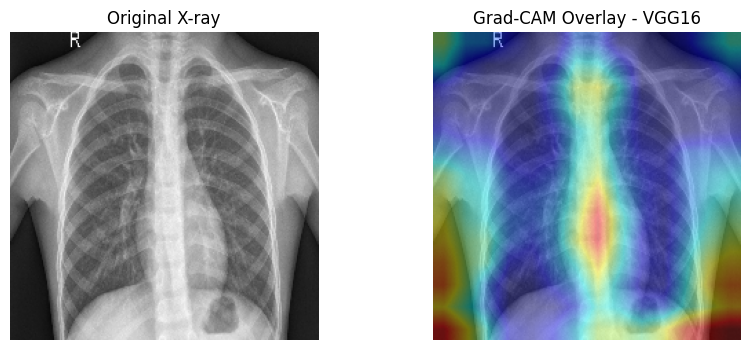

In [24]:
# STEP 13B: Grad-CAM Overlay on Original X-ray

img_original = cv2.imread(img_path)
img_original = cv2.resize(img_original, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)

heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay - VGG16")
plt.axis("off")

plt.show()

In [25]:
!ls -lh /content/model_checkpoints

total 850M
-rw-r--r-- 1 root root 128M May 20 18:08 baseline_cnn_epoch_10.keras
-rw-r--r-- 1 root root 128M May 20 18:26 baseline_cnn_epoch_20.keras
-rw-r--r-- 1 root root 128M May 20 18:45 baseline_cnn_epoch_30.keras
-rw-r--r-- 1 root root  94M May 20 20:38 resnet50_epoch_10.keras
-rw-r--r-- 1 root root  93M May 20 19:12 vgg16_epoch_10.keras
-rw-r--r-- 1 root root  93M May 20 19:32 vgg16_epoch_20.keras
-rw-r--r-- 1 root root  93M May 20 19:51 vgg16_epoch_30.keras
-rw-r--r-- 1 root root  93M May 20 20:11 vgg16_epoch_40.keras
